**CIS 5190 Final Project - Topic B**

Environment setup

In [1]:
# !pip install pandas numpy requests beautifulsoup4 lxml tqdm nltk scikit-learn matplotlib seaborn wordcloud curl_cffi

In [2]:
!pip install lxml curl_cffi 

  Using cached lxml-6.1.0-cp310-cp310-macosx_10_9_universal2.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 368.3 kB/s  0:00:23m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 171.0 kB/s  0:00:14 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [curl_cffi]/5 [curl_cffi]t-py]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import re
import time
import json
import random
import string
from pathlib import Path
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 120)

In [4]:
# Paths
PROJECT_ROOT = Path('.').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR = PROJECT_ROOT / 'figures'
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Input: the CSV provided by the course containing the ~3815 URLs
RAW_URL_CSV = PROJECT_ROOT / 'url_only_data.csv'

# Outputs
SCRAPED_CSV  = DATA_DIR / 'scraped_raw.csv'
CLEANED_CSV  = DATA_DIR / 'cleaned.csv'
TRAIN_CSV    = DATA_DIR / 'train.csv'
VAL_CSV      = DATA_DIR / 'val.csv'
TEST_CSV     = DATA_DIR / 'test.csv'

print('Project root :', PROJECT_ROOT)
print('Data dir     :', DATA_DIR)

Project root : /Users/tteresattian/Desktop/5190finalproj
Data dir     : /Users/tteresattian/Desktop/5190finalproj/data


## 1. Load URL list

The course CSV has Fox News URLs at the top and NBC URLs at the bottom. The cell below:
- Auto-detects the URL column (falls back to the first column if the column name is unusual).
- Infers `source` from the domain (`foxnews.com` → FoxNews; `nbcnews.com` / `today.com` → NBC).

In [5]:
def infer_source(url: str) -> str:
    """Return 'FoxNews' / 'NBC' / 'Unknown' based on domain."""
    try:
        host = urlparse(url).netloc.lower()
    except Exception:
        return 'Unknown'
    if 'foxnews.com' in host or 'foxbusiness.com' in host:
        return 'FoxNews'
    if 'nbcnews.com' in host or 'today.com' in host or 'nbc.com' in host:
        return 'NBC'
    return 'Unknown'


if RAW_URL_CSV.exists():
    url_df = pd.read_csv(RAW_URL_CSV)
    print(f'Loaded {len(url_df)} rows from {RAW_URL_CSV.name}')
    print('Columns:', list(url_df.columns))

    # Locate the URL column
    url_col_candidates = [c for c in url_df.columns if 'url' in c.lower() or 'link' in c.lower()]
    url_col = url_col_candidates[0] if url_col_candidates else url_df.columns[0]
    url_df = url_df.rename(columns={url_col: 'url'})

    # If there's no explicit source/label column, infer from domain
    if 'source' not in url_df.columns and 'label' not in url_df.columns:
        url_df['source'] = url_df['url'].apply(infer_source)

    url_df = url_df[['url', 'source']].dropna(subset=['url']).reset_index(drop=True)
    display(url_df.head())
    print('\nSource distribution:')
    print(url_df['source'].value_counts())
else:
    print(f'[WARN] {RAW_URL_CSV} not found. Place the course-provided CSV there and re-run this cell.')
    url_df = None

Loaded 3805 rows from url_only_data.csv
Columns: ['url']


,url,source
0,https://www.foxnews.com/lifestyle/jack-carrs-eisenhower-d-days-memo-noble-undertaking,FoxNews
1,https://www.foxnews.com/entertainment/bruce-willis-demi-moore-avoided-doing-one-thing-while-co-parenting-daughter-says,FoxNews
2,https://www.foxnews.com/politics/blinken-meets-with-qatars-prime-minister.print,FoxNews
3,https://www.foxnews.com/entertainment/emily-blunt-says-toes-curl-when-people-their-kids-want-act-want-say-dont-do-it,FoxNews
4,https://www.foxnews.com/media/the-view-co-host-cnn-commentator-ana-navarro-host-night-2-democratic-national-convention,FoxNews



Source distribution:
source
FoxNews    2000
NBC        1805
Name: count, dtype: int64


## 2. Web scraping (first pass — fast & light)

**Strategy**:
- Site-specific `<h1>` selectors first; fall back to `<meta property="og:title">` and then `<title>`.
- Minimal headers (just UA + `Accept-Language`), modest retries, `ThreadPoolExecutor` with `max_workers=8`.
- This pass is meant to be **fast** — it will succeed on the easy majority (basically all NBC + most Fox URLs).
- Failures are logged to `data/failed_urls.csv` and handled by the heavy-armor retry in section 2b.


In [6]:
USER_AGENTS = [
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.0 Safari/605.1.15',
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36',
    'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36',
]

FOX_SELECTORS = [
    ('h1', {'class_': 'headline speakable'}),
    ('h1', {'class_': 'headline'}),
]
NBC_SELECTORS = [
    ('h1', {'class_': lambda c: c and 'article-hero-headline' in c}),
    ('h1', {'class_': lambda c: c and 'headline' in c}),
    ('h1', {}),
]

def _extract_from_selectors(soup, selectors):
    for tag, kwargs in selectors:
        node = soup.find(tag, **kwargs)
        if node and node.get_text(strip=True):
            return node.get_text(strip=True)
    return None

def extract_headline(html: str, source: str) -> str:
    soup = BeautifulSoup(html, 'lxml')
    if source == 'FoxNews':
        t = _extract_from_selectors(soup, FOX_SELECTORS)
    elif source == 'NBC':
        t = _extract_from_selectors(soup, NBC_SELECTORS)
    else:
        t = _extract_from_selectors(soup, FOX_SELECTORS + NBC_SELECTORS)
    if t:
        return t
    og = soup.find('meta', property='og:title')
    if og and og.get('content'):
        return og['content'].strip()
    if soup.title and soup.title.string:
        return soup.title.string.strip()
    return ''

def fetch(url: str, source: str, timeout: int = 12, max_retries: int = 3):
    """Lightweight fetch: minimal headers, 3 retries on 403/429. Fast path."""
    headers = {'User-Agent': random.choice(USER_AGENTS), 'Accept-Language': 'en-US,en;q=0.9'}
    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=headers, timeout=timeout)
            if r.status_code == 200:
                return {
                    'url': url,
                    'source': source,
                    'headline': extract_headline(r.text, source),
                    'status': 200,
                    'error': None,
                }
            if r.status_code in (403, 429):
                time.sleep(2 ** attempt + random.random())
                continue
            return {'url': url, 'source': source, 'headline': '', 'status': r.status_code, 'error': f'HTTP {r.status_code}'}
        except Exception as e:
            if attempt == max_retries - 1:
                return {'url': url, 'source': source, 'headline': '', 'status': -1, 'error': str(e)[:200]}
            time.sleep(2 ** attempt + random.random())


In [7]:
def scrape_all(df_urls: pd.DataFrame, max_workers: int = 8, resume: bool = True) -> pd.DataFrame:
    """Concurrent scrape. If scraped_raw.csv exists and resume=True, skip URLs already fetched."""
    done = pd.DataFrame()
    if resume and SCRAPED_CSV.exists():
        done = pd.read_csv(SCRAPED_CSV)
        print(f'Resume: {len(done)} URLs already scraped.')
    done_urls = set(done['url']) if len(done) else set()
    todo = df_urls[~df_urls['url'].isin(done_urls)].reset_index(drop=True)
    print(f'Scraping {len(todo)} URLs ...')

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(fetch, row.url, row.source): row for row in todo.itertuples(index=False)}
        for fut in tqdm(as_completed(futures), total=len(futures)):
            results.append(fut.result())

    new_df = pd.DataFrame(results)
    combined = pd.concat([done, new_df], ignore_index=True) if len(done) else new_df
    combined.to_csv(SCRAPED_CSV, index=False)
    print(f'Saved {len(combined)} rows to {SCRAPED_CSV}')
    return combined


In [8]:
# --- Run the fast first pass ---
# Tip: for a quick sanity check, replace url_df with url_df.head(50)

if url_df is not None:
    scraped = scrape_all(url_df, max_workers=8, resume=True)
else:
    scraped = pd.read_csv(SCRAPED_CSV) if SCRAPED_CSV.exists() else None

if scraped is not None:
    print('\nFirst-pass scrape summary:')
    print(f"  total         : {len(scraped)}")
    print(f"  HTTP 200      : {(scraped['status']==200).sum()}")
    print(f"  non-empty     : {scraped['headline'].astype(str).str.len().gt(0).sum()}")
    print(f"  Fox rows (ok) : {((scraped['source']=='FoxNews') & (scraped['status']==200)).sum()}")
    print(f"  NBC rows (ok) : {((scraped['source']=='NBC')     & (scraped['status']==200)).sum()}")
    display(scraped.head())

    failed = scraped[(scraped['status']!=200) | (scraped['headline'].astype(str).str.len()==0)]
    failed.to_csv(DATA_DIR / 'failed_urls.csv', index=False)
    print(f"  failed URLs   : {len(failed)}  (saved to data/failed_urls.csv — handled in section 2b)")


Resume: 3805 URLs already scraped.
Scraping 0 URLs ...


0it [00:00, ?it/s]

Saved 3805 rows to /Users/tteresattian/Desktop/5190finalproj/data/scraped_raw.csv

First-pass scrape summary:
  total         : 3805
  HTTP 200      : 0
  non-empty     : 3805
  Fox rows (ok) : 0
  NBC rows (ok) : 0


,url,source,headline,status,error
0,http://www.foxnews.com/entertainment/lori-loughlin-mossimo-giannulli-asks-serve-remainder-prison-sentence-home,FoxNews,NaN,-1,"HTTPConnectionPool(host='www.foxnews.com', port=80): Max retries exceeded with url: /entertainment/lori-loughlin-mos..."
1,https://foxnews.com/politics/back-trail-top-biden-surrogate-newsom-now-campaigning-harris,FoxNews,NaN,-1,"HTTPSConnectionPool(host='foxnews.com', port=443): Max retries exceeded with url: /politics/back-trail-top-biden-sur..."
2,https://foxnews.com/politics/harris-claims-trump-abortion-platform-makes-no-exception-moments-after-trump-says-oppos...,FoxNews,NaN,-1,"HTTPSConnectionPool(host='foxnews.com', port=443): Max retries exceeded with url: /politics/harris-claims-trump-abor..."
3,https://foxnews.com/politics/jimmy-carters-family-reveals-how-president-felt-about-biden-quitting-which-dnc-speaker-...,FoxNews,NaN,-1,"HTTPSConnectionPool(host='foxnews.com', port=443): Max retries exceeded with url: /politics/jimmy-carters-family-rev..."
4,https://foxnews.com/politics/new-poll-reveals-what-democrats-think-harris-president,FoxNews,NaN,-1,"HTTPSConnectionPool(host='foxnews.com', port=443): Max retries exceeded with url: /politics/new-poll-reveals-what-de..."


  failed URLs   : 3805  (saved to data/failed_urls.csv — handled in section 2b)


## 2b. Retry failed URLs (heavy armor)

The first pass is deliberately fast and will leave behind the URLs that Fox's WAF
rejects with HTTP 406 (plus some `.print` stubs). We retry **only the failures** with:

- Full browser-like header block (`Accept`, `Accept-Encoding`, `Sec-Fetch-*`, `Referer`, …).
- Optional TLS fingerprint spoofing via `curl_cffi` if installed — the big win against
  Akamai/Imperva-fronted sites. `pip install curl_cffi` and restart the kernel to enable it.
- `.print` suffix stripped and URL fragments (`#…`) removed before the request.
- UA rotated every attempt, 406 triggers retry, low per-domain concurrency.
- NBC 404/410/500 are real dead links — not retried.


In [9]:
# curl_cffi is optional but dramatically reduces FoxNews 406s.
# Install with: pip install curl_cffi   (then restart the kernel)
try:
    from curl_cffi import requests as _cffi
    HAVE_CFFI = True
except Exception:
    HAVE_CFFI = False
print(f'curl_cffi available: {HAVE_CFFI}')

BROWSER_HEADERS = {
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.9',
    'Accept-Encoding': 'gzip, deflate, br',
    'Upgrade-Insecure-Requests': '1',
    'Sec-Fetch-Dest': 'document',
    'Sec-Fetch-Mode': 'navigate',
    'Sec-Fetch-Site': 'none',
    'Sec-Fetch-User': '?1',
    'Cache-Control': 'max-age=0',
    'Connection': 'keep-alive',
}

REFERERS = {
    'FoxNews': 'https://www.foxnews.com/',
    'NBC': 'https://www.nbcnews.com/',
}

def normalize_url(u: str) -> str:
    """Drop fragments and the Fox '.print' suffix. '#' content is never sent to
    the server anyway, and '.print' copies are mostly 404/406 while the canonical
    URL is live."""
    u = str(u).split('#', 1)[0].strip()
    if u.endswith('.print'):
        u = u[:-len('.print')]
    return u

def fetch_retry(url: str, source: str, timeout: int = 15, max_retries: int = 4):
    """Heavy-armor fetch: browser headers, UA rotation, 406 retry, optional curl_cffi."""
    last_status, last_err = -1, None
    for attempt in range(max_retries):
        headers = dict(BROWSER_HEADERS)
        headers['User-Agent'] = random.choice(USER_AGENTS)
        headers['Referer'] = REFERERS.get(source, 'https://www.google.com/')
        try:
            if HAVE_CFFI:
                r = _cffi.get(url, headers=headers, timeout=timeout, impersonate='chrome124')
            else:
                r = requests.get(url, headers=headers, timeout=timeout)
            last_status = r.status_code
            if r.status_code == 200 and r.text:
                return {
                    'url': url,
                    'source': source,
                    'headline': extract_headline(r.text, source),
                    'status': 200,
                    'error': None,
                }
            if r.status_code in (403, 406, 429, 503):
                time.sleep(2 ** attempt + random.random())
                continue
            return {'url': url, 'source': source, 'headline': '', 'status': r.status_code, 'error': f'HTTP {r.status_code}'}
        except Exception as e:
            last_err = str(e)[:200]
            if attempt == max_retries - 1:
                return {'url': url, 'source': source, 'headline': '', 'status': -1, 'error': last_err}
            time.sleep(2 ** attempt + random.random())
    return {'url': url, 'source': source, 'headline': '', 'status': last_status, 'error': last_err or f'HTTP {last_status}'}

def retry_failed(failed_csv=DATA_DIR / 'failed_urls.csv',
                 scraped_csv=SCRAPED_CSV,
                 max_workers: int = 3,
                 skip_statuses=(404, 410)):
    """Re-scrape every URL in failed_urls.csv and merge successful rows back into
    scraped_raw.csv. Merge is done on normalized URL so a stale '.../x.print'
    (status=406) row is properly replaced by the recovered '.../x' row."""
    if not failed_csv.exists():
        print(f'No failure log at {failed_csv} — nothing to retry.')
        return None

    failed = pd.read_csv(failed_csv)
    failed = failed[failed['source'].isin(['FoxNews', 'NBC'])].copy()
    failed = failed[~failed['status'].isin(skip_statuses)].copy()
    failed['url_norm'] = failed['url'].astype(str).map(normalize_url)
    failed = failed.drop_duplicates(subset=['url_norm']).reset_index(drop=True)
    print(f'Retrying {len(failed)} URLs (max_workers={max_workers}, curl_cffi={HAVE_CFFI}) ...')

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(fetch_retry, row.url_norm, row.source): row for row in failed.itertuples(index=False)}
        for fut in tqdm(as_completed(futures), total=len(futures)):
            results.append(fut.result())

    retry_df = pd.DataFrame(results)
    n_ok = int((retry_df['status'] == 200).sum())
    print(f'Retry result: {n_ok}/{len(retry_df)} succeeded ({n_ok/max(len(retry_df),1):.1%})')

    if scraped_csv.exists():
        scraped = pd.read_csv(scraped_csv)
        scraped['_url_norm'] = scraped['url'].astype(str).map(normalize_url)
        good = retry_df[retry_df['status'] == 200][['url', 'source', 'headline', 'status', 'error']].copy()
        good['_url_norm'] = good['url'].astype(str).map(normalize_url)
        scraped = scraped[~scraped['_url_norm'].isin(good['_url_norm'])]
        merged = (pd.concat([scraped, good], ignore_index=True).drop(columns='_url_norm'))
        merged.to_csv(scraped_csv, index=False)
        print(f'Merged {len(good)} recovered rows into {scraped_csv} (now {len(merged)} total)')

    still_failed = retry_df[retry_df['status'] != 200]
    still_failed.to_csv(failed_csv, index=False)
    print(f'Remaining failures: {len(still_failed)} (rewrote {failed_csv})')
    return retry_df


curl_cffi available: True


### Rerun the following cell multiple times.

In [10]:
# Run the retry. Safe to re-run — rewrites failed_urls.csv each pass with only the
# URLs still failing, so repeated calls converge.
retry_df = retry_failed(max_workers=3)
if retry_df is not None:
    print('\nStatus breakdown after retry:')
    print(retry_df['status'].value_counts().to_string())

# Reload scraped from disk + dedup any leftover .print stubs, so every downstream
# cell (cleaning / normalization / split / EDA) sees the recovered rows.
if SCRAPED_CSV.exists():
    scraped = pd.read_csv(SCRAPED_CSV)
    scraped['_url_norm'] = scraped['url'].astype(str).map(normalize_url)
    scraped['_is_ok'] = (scraped['status'] == 200).astype(int)
    scraped = (scraped.sort_values(['_url_norm', '_is_ok'], ascending=[True, False])
                      .drop_duplicates(subset='_url_norm', keep='first')
                      .drop(columns=['_url_norm', '_is_ok'])
                      .reset_index(drop=True))
    scraped.to_csv(SCRAPED_CSV, index=False)

    failed = scraped[(scraped['status'] != 200) | (scraped['headline'].astype(str).str.len() == 0)]
    print('\nFinal scrape state (after retry merge + .print dedup):')
    print(f"  total         : {len(scraped)}")
    print(f"  HTTP 200      : {(scraped['status']==200).sum()}")
    print(f"  non-empty     : {scraped['headline'].astype(str).str.len().gt(0).sum()}")
    print(f"  Fox rows (ok) : {((scraped['source']=='FoxNews') & (scraped['status']==200)).sum()}")
    print(f"  NBC rows (ok) : {((scraped['source']=='NBC')     & (scraped['status']==200)).sum()}")
    print(f"  still failing : {len(failed)}")


Retrying 3805 URLs (max_workers=3, curl_cffi=True) ...


  0%|          | 0/3805 [00:00<?, ?it/s]

Retry result: 3801/3805 succeeded (99.9%)
Merged 3801 recovered rows into /Users/tteresattian/Desktop/5190finalproj/data/scraped_raw.csv (now 3805 total)
Remaining failures: 4 (rewrote /Users/tteresattian/Desktop/5190finalproj/data/failed_urls.csv)

Status breakdown after retry:
status
200    3801
500       2
404       1
410       1

Final scrape state (after retry merge + .print dedup):
  total         : 3805
  HTTP 200      : 3801
  non-empty     : 3805
  Fox rows (ok) : 2000
  NBC rows (ok) : 1801
  still failing : 4


## 3. Text cleaning

- Remove HTML residue, decode HTML entities, convert NBSP.
- Normalize smart quotes and em/en dashes.
- Collapse whitespace, trim leading/trailing quotes.
- Drop empty headlines and duplicates.

In [11]:
HTML_TAG_RE = re.compile(r'<[^>]+>')
MULTI_WS_RE = re.compile(r'\s+')


def clean_headline(text: str) -> str:
    if not isinstance(text, str):
        return ''
    t = text
    # HTML residue
    t = HTML_TAG_RE.sub(' ', t)
    # HTML entities
    t = (t.replace('&amp;', '&').replace('&quot;', '"').replace('&apos;', "'")
          .replace('&#39;', "'").replace('&nbsp;', ' ').replace('\xa0', ' ')
          .replace('&lt;', '<').replace('&gt;', '>'))
    # Smart quotes / dashes -> ASCII
    t = (t.replace('\u2018', "'").replace('\u2019', "'")
          .replace('\u201c', '"').replace('\u201d', '"')
          .replace('\u2013', '-').replace('\u2014', '-'))
    # Strip leading/trailing quotes and whitespace
    t = t.strip().strip('"').strip("'").strip()
    # Collapse internal whitespace
    t = MULTI_WS_RE.sub(' ', t).strip()
    return t


if scraped is not None:
    df = scraped.copy()
    df['headline_clean'] = df['headline'].apply(clean_headline)

    # Filter invalid rows
    before = len(df)
    df = df[df['headline_clean'].str.len() >= 5]                 # too short -> skip
    df = df[df['source'].isin(['FoxNews', 'NBC'])]               # keep only the two sources
    df = df.drop_duplicates(subset=['headline_clean'])           # exact dedup
    df = df.reset_index(drop=True)
    print(f'Cleaning: {before} -> {len(df)}  (removed {before-len(df)})')

    display(df[['source', 'headline_clean']].head(10))

Cleaning: 3805 -> 3783  (removed 22)


,source,headline_clean
0,FoxNews,Lori Loughlin's husband Mossimo Giannulli asks to serve remainder of five-month prison sentence at home
1,FoxNews,Back on the trail: Top Biden surrogate Newsom now campaigning for Harris
2,FoxNews,"Harris claims Trump abortion platform makes 'no exception,' moments after Trump says the opposite"
3,FoxNews,"Jimmy Carter's family reveals how president felt about Biden quitting, which DNC speaker stole the show"
4,FoxNews,New poll reveals what Democrats think of Harris as president
5,FoxNews,Taylor Swift endorses Kamala Harris for president after debate: 'I've made my choice
6,FoxNews,"Trump, Harris trade barbs on crime during first presidential debate: 'Through the roof"
7,FoxNews,Trump says he 'probably took a bullet to the head' due to Dem rhetoric
8,FoxNews,"Trump spars with Harris, moderators during heated presidential debate: 'She doesn't have a plan"
9,FoxNews,NBA great Magic Johnson slammed for calling Obama's DNC speeches the best in 'history of our country


## 4. Normalization (2 versions for different models)

Two text columns are produced so downstream code can pick the appropriate one:
- `headline_clean` — cleaned but original casing/punctuation preserved. **Recommended for Transformer models (BERT, RoBERTa, ...).**
- `headline_norm`  — lowercased, punctuation removed, stopwords removed, lemmatized. **Recommended for classical TF-IDF + linear models.**

In [12]:
import nltk

# NLTK resources.  Newer NLTK (>= 3.9) uses 'punkt_tab' instead of 'punkt';
# we request both so the notebook works across versions.
NLTK_RESOURCES = [
    ('corpora/stopwords',    'stopwords'),
    ('corpora/wordnet',      'wordnet'),
    ('corpora/omw-1.4',      'omw-1.4'),
    ('tokenizers/punkt',     'punkt'),
    ('tokenizers/punkt_tab', 'punkt_tab'),
]
for path, pkg in NLTK_RESOURCES:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS   = set(stopwords.words('english'))
LEMMATIZER  = WordNetLemmatizer()
PUNCT_TABLE = str.maketrans('', '', string.punctuation)

# Simple regex tokenizer.  We've already stripped punctuation,
# so we do not need nltk.word_tokenize (which depends on punkt_tab data
# and breaks between NLTK versions).  Keep only ASCII alphabetic tokens.
_TOKEN_RE = re.compile(r"[a-z]+")

def normalize(text: str) -> str:
    if not isinstance(text, str):
        return ''
    t = text.lower().translate(PUNCT_TABLE)
    tokens = _TOKEN_RE.findall(t)
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens
              if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

if 'df' in globals() and df is not None:
    df['headline_norm'] = df['headline_clean'].apply(normalize)
    # Drop rows whose normalized form ended up empty (all stopwords, etc.)
    before = len(df)
    df = df[df['headline_norm'].str.len() > 0].reset_index(drop=True)
    print(f'After normalization filter: {before} -> {len(df)}')
    display(df[['headline_clean', 'headline_norm']].head(5))


After normalization filter: 3783 -> 3783


,headline_clean,headline_norm
0,Lori Loughlin's husband Mossimo Giannulli asks to serve remainder of five-month prison sentence at home,lori loughlins husband mossimo giannulli asks serve remainder fivemonth prison sentence home
1,Back on the trail: Top Biden surrogate Newsom now campaigning for Harris,back trail top biden surrogate newsom campaigning harris
2,"Harris claims Trump abortion platform makes 'no exception,' moments after Trump says the opposite",harris claim trump abortion platform make exception moment trump say opposite
3,"Jimmy Carter's family reveals how president felt about Biden quitting, which DNC speaker stole the show",jimmy carter family reveals president felt biden quitting dnc speaker stole show
4,New poll reveals what Democrats think of Harris as president,new poll reveals democrat think harris president


## 5. Consistency checks & label encoding

In [13]:
def run_consistency_checks(df):
    """Consistency checks on the cleaned dataframe.
    Returns {check_name: (passed: bool, detail: str)}.  Prints a report; does not raise.
    """
    report = {}

    # 1. Label <-> URL domain consistency
    def _dom(url):
        try:
            host = urlparse(str(url)).netloc.lower()
        except Exception:
            return 'Unknown'
        if 'foxnews.com' in host or 'foxbusiness.com' in host: return 'FoxNews'
        if 'nbcnews.com' in host or 'today.com' in host or 'nbc.com' in host: return 'NBC'
        return 'Unknown'
    mis = df[df['url'].apply(_dom) != df['source']]
    report['label_url_match'] = (len(mis)==0, f'{len(mis)} rows where URL domain != source')

    # 2. No empty / NaN headlines
    ec = df['headline_clean'].isna() | (df['headline_clean'].astype(str).str.len()==0)
    en = df['headline_norm'].isna()  | (df['headline_norm'].astype(str).str.len() ==0)
    report['no_empty_clean'] = (ec.sum()==0, f'{ec.sum()} empty headline_clean')
    report['no_empty_norm']  = (en.sum()==0, f'{en.sum()} empty headline_norm')

    # 3. Length sanity (3..40 words is a reasonable headline)
    wc = df['headline_clean'].str.split().str.len()
    report['length_sanity'] = ((wc<3).sum()==0 and (wc>40).sum()==0,
                               f'{(wc<3).sum()} <3 words, {(wc>40).sum()} >40 words')

    # 4. No exact duplicates
    dc = df.duplicated(subset=['headline_clean']).sum()
    dn = df.duplicated(subset=['headline_norm']).sum()
    report['no_duplicates'] = (dc==0 and dn==0, f'{dc} dup clean, {dn} dup norm')

    # 5. Label binary
    lbl = set(df['label'].unique())
    report['label_binary'] = (lbl=={0,1}, f'label values = {sorted(lbl)}')

    # 6. Class balance reasonable
    fr = (df['label']==1).mean()
    report['class_balance'] = (0.05<=fr<=0.95, f'Fox rate = {fr:.3f}')

    # pretty print
    w = max(len(k) for k in report)
    print('Consistency checks')
    print('-'*72)
    for n,(ok,d) in report.items():
        print(f'  {"[PASS]" if ok else "[FAIL]"}  {n:<{w}}  {d}')
    npass = sum(v[0] for v in report.values())
    print('-'*72)
    print(f'  {npass}/{len(report)} checks passed')

    if len(mis) > 0:
        print('\nSample label/URL mismatches:'); display(mis[['url','source']].head(5))

    return report


if 'df' in globals() and df is not None:
    # --- Cleanup pass 1: drop rows with too-short cleaned headlines (<3 words)
    wc = df['headline_clean'].str.split().str.len()
    if (wc < 3).any():
        print(f'Dropping {int((wc<3).sum())} rows shorter than 3 words.')
        df = df[wc >= 3].reset_index(drop=True)

    # --- Cleanup pass 2: dedup on the normalized text
    before = len(df)
    df = df.drop_duplicates(subset=['headline_norm']).reset_index(drop=True)
    if before != len(df):
        print(f'Dedup by normalized text: {before} -> {len(df)}')

    # --- Label encoding: FoxNews = 1, NBC = 0
    df['label'] = (df['source'] == 'FoxNews').astype(int)

    # --- Run consistency checks on the result
    print()
    checks = run_consistency_checks(df)

    print('\nClass distribution:')
    print(df['source'].value_counts())
    print(f"Positive-class rate (Fox / total): {df['label'].mean():.3f}")

    df.to_csv(CLEANED_CSV, index=False)
    print(f'\nSaved cleaned -> {CLEANED_CSV}')

Dropping 1 rows shorter than 3 words.

Consistency checks
------------------------------------------------------------------------
  [PASS]  label_url_match  0 rows where URL domain != source
  [PASS]  no_empty_clean   0 empty headline_clean
  [PASS]  no_empty_norm    0 empty headline_norm
  [PASS]  length_sanity    0 <3 words, 0 >40 words
  [PASS]  no_duplicates    0 dup clean, 0 dup norm
  [PASS]  label_binary     label values = [0, 1]
  [PASS]  class_balance    Fox rate = 0.529
------------------------------------------------------------------------
  7/7 checks passed

Class distribution:
source
FoxNews    2000
NBC        1782
Name: count, dtype: int64
Positive-class rate (Fox / total): 0.529

Saved cleaned -> /Users/tteresattian/Desktop/5190finalproj/data/cleaned.csv


## 6. Exploratory Data Analysis

Headline length stats:


char_len                                             word_len        \
           count  mean   std   min   25%   50%    75%    max    count  mean   
source                                                                        
FoxNews   2000.0  88.5  15.0  29.0  78.0  90.0  101.0  110.0   2000.0  13.8   
NBC       1782.0  77.0  16.9  22.0  66.0  77.0   88.0  158.0   1782.0  12.4   

                                           
         std  min   25%   50%   75%   max  
source                                     
FoxNews  2.6  5.0  12.0  14.0  16.0  22.0  
NBC      2.9  4.0  10.0  12.0  14.0  25.0

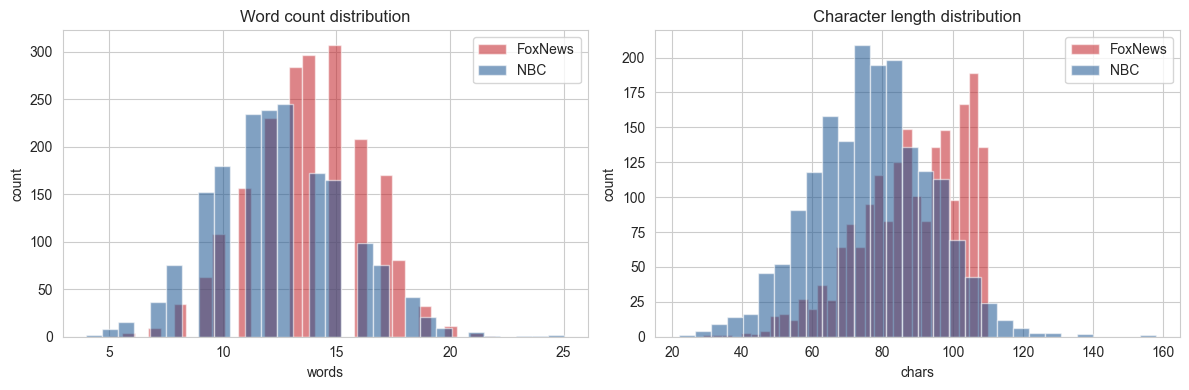

In [14]:
if 'df' in globals() and df is not None:
    df['char_len']  = df['headline_clean'].str.len()
    df['word_len']  = df['headline_clean'].str.split().str.len()

    print('Headline length stats:')
    display(df.groupby('source')[['char_len', 'word_len']].describe().round(1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for src, color in zip(['FoxNews', 'NBC'], ['#c22026', '#1a5490']):
        subset = df[df['source']==src]
        axes[0].hist(subset['word_len'], bins=30, alpha=0.55, label=src, color=color)
        axes[1].hist(subset['char_len'], bins=30, alpha=0.55, label=src, color=color)
    axes[0].set(title='Word count distribution', xlabel='words', ylabel='count')
    axes[1].set(title='Character length distribution', xlabel='chars', ylabel='count')
    for ax in axes: ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'headline_length.png', dpi=120)
    plt.show()

In [15]:
# Class-distinctive words via log-odds with add-1 smoothing
from collections import Counter

def top_words_by_class(df, col='headline_norm', top_k=20):
    def tok(text): return text.split()
    fox_counts = Counter()
    nbc_counts = Counter()
    for row in df.itertuples():
        (fox_counts if row.source=='FoxNews' else nbc_counts).update(tok(getattr(row, col)))
    vocab = set(fox_counts) | set(nbc_counts)
    fox_total = sum(fox_counts.values()) + len(vocab)
    nbc_total = sum(nbc_counts.values()) + len(vocab)
    scores = {}
    for w in vocab:
        p_fox = (fox_counts[w] + 1) / fox_total
        p_nbc = (nbc_counts[w] + 1) / nbc_total
        scores[w] = np.log(p_fox / p_nbc)
    ranked = sorted(scores.items(), key=lambda kv: kv[1])
    return ranked[-top_k:][::-1], ranked[:top_k]

if 'df' in globals() and df is not None:
    fox_top, nbc_top = top_words_by_class(df, top_k=20)
    print('Fox-leaning words:')
    for w, s in fox_top: print(f'  {w:20s}  {s:+.3f}')
    print('\nNBC-leaning words:')
    for w, s in nbc_top: print(f'  {w:20s}  {s:+.3f}')

Fox-leaning words:
  cnn                   +3.475
  dem                   +3.179
  dems                  +2.947
  bruce                 +2.856
  antiisrael            +2.756
  john                  +2.702
  dinner                +2.645
  cnns                  +2.645
  bidenharris           +2.645
  disease               +2.645
  dementia              +2.584
  title                 +2.451
  venezuelan            +2.451
  sydney                +2.451
  daughter              +2.377
  ix                    +2.377
  stelter               +2.377
  network               +2.377
  scandal               +2.297
  sweeney               +2.297

NBC-leaning words:
  jan                   -3.772
  rioter                -3.622
  product               -3.446
  israelhamas           -3.079
  puerto                -3.022
  west                  -2.896
  tested                -2.896
  bangladesh            -2.753
  conspiracy            -2.753
  dermatologist         -2.753
  amazon                -2.714
